# 실전 10-2: Supervisor Workflow (팀장 결재 라인 구축)

## 1. 실험 목적
- **문제점**: 앞선 01번 노트북에서는 사람이 일일이 "리서처님 이거 하세요", "분석가님 저거 하세요"라고 각각 지시를 내려야 했습니다.
- **해결책**: **LangGraph**를 활용하여, 대빵인 **[팀장(Supervisor) 에이전트]**를 중앙에 배치합니다. 사용자가 "애플 관련 뉴스를 찾고 주가 차트를 그려줘"라고 팀장에게 한 번만 말하면, 팀장이 알아서 리서처에게 검색을 지시하고, 그 결과를 분석가에게 넘겨 코드를 짜게 한 뒤, 모든 일이 끝나면 사용자에게 최종 보고하는 완벽한 자동화 팀을 만듭니다.

In [1]:
import os
from typing import Annotated, Any, Sequence, TypedDict
import operator
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_experimental.tools import PythonREPLTool

from langgraph.graph import StateGraph, END
from langchain.agents import create_agent

load_dotenv()
llm = ChatOpenAI(model="gpt-4o")

C:\Users\USER\AppData\Local\Temp\ipykernel_22680\2360773988.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun
C:\Users\USER\AppData\Local\Temp\ipykernel_22680\2360773988.py:10: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  from langchain_experimental.tools import PythonREPLTool


## 2. 상태(State) 및 도구 준비
팀 전체가 공유할 화이트보드(State)와 도구들을 세팅합니다.

In [2]:
# 1. 팀의 화이트보드(State)
# 지금까지의 모든 대화 기록을 담고, 팀장이 다음으로 누구를 부를지(next) 결정하는 변수를 가집니다.
class TeamState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], operator.add]
    next: str

# 2. 도구
search_tool = DuckDuckGoSearchRun()
python_repl_tool = PythonREPLTool()

## 3. 노드(Node) 정의: 최신 create_agent 활용
각 요원(리서처, 분석가)은 LangGraph의 노드(Node)로 작동하게 됩니다. 최신 `create_agent` 함수를 사용하여 코드를 극도로 간결하게 만듭니다.

In [3]:
# 각 에이전트가 일을 마치면, 자신의 이름표를 달아서 화이트보드(State)에 결과를 적도록 하는 래퍼(Wrapper) 함수
def agent_node(state, agent, name):
    result = agent.invoke(state)
    # 최신 create_agent는 상태 그래프를 반환하므로 결과 메세지가 result["messages"][-1]에 담깁니다.
    return {"messages": [HumanMessage(content=result["messages"][-1].content, name=name)]}

# 리서처 노드 생성
researcher_agent = create_agent(model=llm, tools=[search_tool], system_prompt="당신은 웹 리서처입니다. 정확하게 검색하고 요약하세요.")
researcher_node = lambda state: agent_node(state, researcher_agent, "Researcher")

# 분석가 노드 생성
analyst_agent = create_agent(model=llm, tools=[python_repl_tool], 
    system_prompt="당신은 파이썬 데이터 분석가입니다. 주어지는 데이터를 바탕으로 코드를 짜고 차트를 그리세요.")
analyst_node = lambda state: agent_node(state, analyst_agent, "Analyst")

## 4. 팀장(Supervisor) 에이전트 생성
팀장의 역할은 직접 일을 하는 것이 아니라, **"다음엔 누가 일해!"** 라고 라우팅(Routing)만 해주는 것입니다.

In [4]:
members = ["Researcher", "Analyst"]
options = ["FINISH"] + members

# 팀장이 결정해야 할 형식(Structured Output)
from pydantic import BaseModel
class RouteOutput(BaseModel):
    next: str

# 팀장 프롬프트
supervisor_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 팀장입니다. 주어진 대화 내역을 보고 다음 업무를 누구에게 넘길지 결정하세요.
    멤버는 다음과 같습니다: {members}
    만약 사용자의 요청이 모두 완벽히 해결되었다면 'FINISH'를 출력하세요.
    """),
    MessagesPlaceholder(variable_name="messages")
]).partial(members=", ".join(members))

# 팀장 체인 생성
supervisor_chain = supervisor_prompt | llm.with_structured_output(RouteOutput)

## 5. LangGraph 조립 (조직도 그리기)

In [5]:
workflow = StateGraph(TeamState)

# 노드 추가 (팀원들 방 만들어주기)
workflow.add_node("Researcher", researcher_node)
workflow.add_node("Analyst", analyst_node)
workflow.add_node("Supervisor", supervisor_chain)

# 엣지(연결) 추가: 팀원들이 일을 마치면 무조건 팀장(Supervisor)에게 결과를 보고하도록 함
workflow.add_edge("Researcher", "Supervisor")
workflow.add_edge("Analyst", "Supervisor")

# 팀장(Supervisor)의 조건부 라우팅 설정
# 팀장이 선택한 next 변수에 따라 다음 팀원을 부르거나, FINISH면 끝(END)냅니다.
workflow.add_conditional_edges(
    "Supervisor",
    lambda state: state["next"],
    {
        "Researcher": "Researcher",
        "Analyst": "Analyst",
        "FINISH": END
    }
)

# 시작점은 무조건 팀장
workflow.set_entry_point("Supervisor")

graph = workflow.compile()

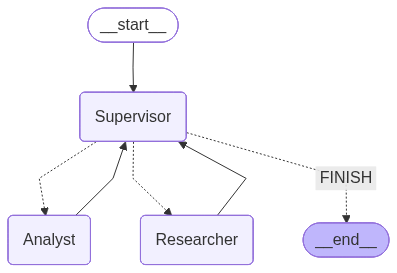

In [6]:
graph

## 6. 최종 테스트 (원클릭 자동화)
자, 이제 팀장에게 복잡한 지시를 하나 던져보겠습니다.
**"최근 구글(GOOGL) 주가 관련 뉴스를 찾고, 지난 3달치 주가 데이터를 다운받아 차트(google_stock.png)로 그려줘"**

=== [팀의 업무 시작] ===

[실행 중인 노드]: Supervisor
--------------------
팀장의 지시: 다음 담당자는 'Researcher' 입니다.

[실행 중인 노드]: Researcher
--------------------
Researcher의 보고:
최근 구글(GOOGL) 주가 관련 뉴스들입니다:

호재 뉴스:
1. **구글 클라우드의 강력한 성장** - 구글의 클라우드 부문은 향후 2년 내에 매출로 인식될 약 1580억 달러의 백로그를 가지고 있습니다. 또한, 온디맨드 부문도 2023년에 29%, 2024년에 37% 성장한 데 이어 올해 약 25% 성장했습니다.

악재 뉴스:
1. **알파벳 주가 급...

[실행 중인 노드]: Supervisor
--------------------
팀장의 지시: 다음 담당자는 'Analyst' 입니다.


Python REPL can execute arbitrary code. Use with caution.
[*********************100%***********************]  1 of 1 completed


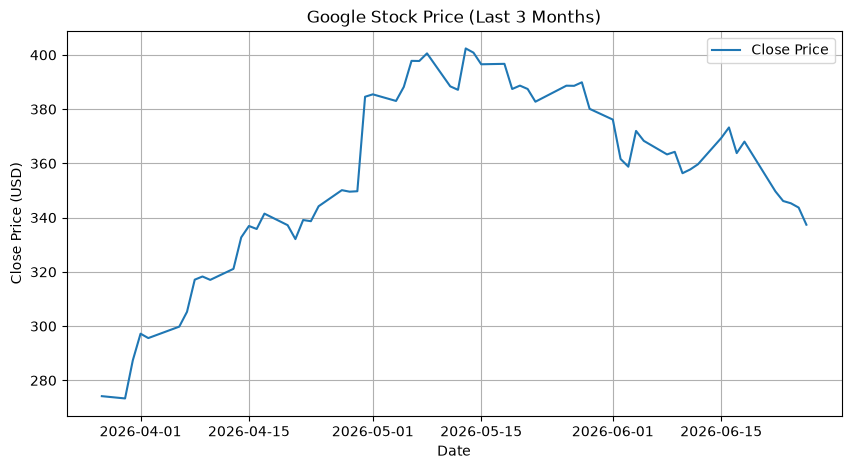


[실행 중인 노드]: Analyst
--------------------
Analyst의 보고:
지난 3개월 동안의 구글 주가 데이터를 기반으로 한 종가 기준 꺾은선 차트가 'google_stock.png' 파일로 성공적으로 저장되었습니다. 이 파일을 열어 차트를 확인하실 수 있습니다....

[실행 중인 노드]: Supervisor
--------------------
팀장의 지시: 다음 담당자는 'FINISH' 입니다.


In [7]:
inputs = {
    "messages": [HumanMessage(content="최근 구글(GOOGL) 주가 관련 호재/악재 뉴스를 2개 정도 찾아줘. 그리고 파이썬으로 지난 3달치 구글 주가 데이터를 다운받아 종가 기준으로 꺾은선 차트를 그리고 'google_stock.png' 파일로 저장해줘.")]
}

print("=== [팀의 업무 시작] ===")
for s in graph.stream(inputs, config={"recursion_limit": 10}):
    if "__end__" not in s:
        print(f"\n[실행 중인 노드]: {list(s.keys())[0]}")
        print("-" * 20)
        # 노드 실행 결과 출력
        node_name = list(s.keys())[0]
        if node_name == "Supervisor":
            print(f"팀장의 지시: 다음 담당자는 '{s[node_name]['next']}' 입니다.")
        else:
            print(f"{node_name}의 보고:\n{s[node_name]['messages'][0].content[:200]}...")

## 7. 결과 해석
결과 로그를 유심히 살펴보세요.
1. **Supervisor**가 처음 입력을 받고, 뉴스 검색이 필요하다고 판단하여 `next='Researcher'`를 선택합니다.
2. **Researcher**가 DuckDuckGo를 통해 구글 뉴스를 긁어오고 팀장에게 보고합니다.
3. **Supervisor**가 이번엔 차트를 그려야 하므로 `next='Analyst'`를 선택합니다.
4. **Analyst**가 파이썬 코드를 찌고 실행(PythonREPLTool)하여 `google_stock.png`를 만듭니다.
5. **Supervisor**가 모든 지시사항이 완료되었음을 확인하고 `FINISH`를 선언하며 종료됩니다.

이것이 바로 여러 AI들이 모여 하나의 가상 회사를 이루는 **Multi-Agent Architecture**의 정수입니다!